# Loading

In [18]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Define the conditions and neuron types
conditions = ['A', 'AV']
neuron_types = ['STRF', 'nSTRF', 'all']
outcome_types = ['hit', 'miss']

# Create a dictionary to store all dataframes
compiled_data = {}

# Compile data for each combination
for condition in conditions:
    for outcome in outcome_types:
        for neuron_type in neuron_types:
            filename = f"{condition}_{outcome}_{neuron_type}.csv"
            if os.path.exists(filename):
                df = pd.read_csv(filename, header=None, names=['connectivity_density'])
                # Add metadata columns
                df['condition'] = condition
                df['outcome'] = outcome
                df['neuron_type'] = neuron_type
                df['filename'] = filename
                compiled_data[filename] = df

# Combine all data into one dataframe
all_data = pd.concat(compiled_data.values(), ignore_index=True)

# Save compiled data
all_data.to_csv('compiled_connectivity_data.csv', index=False)
print("Compiled data saved to 'compiled_connectivity_data.csv'")
print(f"Total rows: {len(all_data)}")
print(f"NaN values: {all_data['connectivity_density'].isna().sum()}")

Compiled data saved to 'compiled_connectivity_data.csv'
Total rows: 876
NaN values: 684


## non-NA trials summary
summary of STRFsig has been compiled and saved as a csv file in advance in /Granger_MSThesis/local/results/STRFsig_summary.csv

In [32]:

STRFsig_summary = pd.read_csv('/Users/wuruoyu/Documents/Granger_MSThesis/local/results/STRFsig_summary.csv')
mat_conditions = ["A-hit","AV-hit","A-miss", "AV-miss"]

for mat_cond in mat_conditions:
    print(f"\n=== {mat_cond} ===")
    print(f"number of files for condition {mat_cond}: {len(STRFsig_summary[STRFsig_summary['condition'] == mat_cond])}")
    n_files_without_STRF = STRFsig_summary[(STRFsig_summary['condition'] == mat_cond) &
                                            (STRFsig_summary['STRF'] == 0)].shape[0]
    print(f"number of files without STRF for condition {mat_cond}: {n_files_without_STRF}")
    n_files_without_nSTRF = STRFsig_summary[(STRFsig_summary['condition'] == mat_cond) &
                                                (STRFsig_summary['nSTRF'] == 0)].shape[0]
    print(f"number of files without nSTRF for condition {mat_cond}: {n_files_without_nSTRF}")
    n_files_with_both_STRF_and_nSTRF = STRFsig_summary[(STRFsig_summary['condition'] == mat_cond) &
                                                        (STRFsig_summary['STRF'] != 0) &
                                                        (STRFsig_summary['nSTRF'] != 0)].shape[0]
    print(f"number of files with both STRF and nSTRF for condition {mat_cond}: {n_files_with_both_STRF_and_nSTRF}")

print("\n=== Summary of Results1 connectivity densities ===")

# Define conditions and outcomes
conditions = [
    ("A", "hit"),
    ("A", "miss"),
    ("AV", "hit"),
    ("AV", "miss")
]

for condition, outcome in conditions:
    results1_filename = f"/Users/wuruoyu/Documents/Granger_MSThesis/local/results/{condition}_{outcome}_connectivity_densities.csv"
    if os.path.exists(results1_filename):
        results1_df = pd.read_csv(results1_filename)
        n_STRF = results1_df[results1_df['STRF'].notna()].shape[0]
        n_nSTRF = results1_df[results1_df['nSTRF'].notna()].shape[0]
        n_all = results1_df[results1_df['all'].notna()].shape[0]
        print(f"{condition} {outcome}: STRF={n_STRF}, nSTRF={n_nSTRF}, all={n_all}")
        
        # Get STRFsig_summary for this condition
        cond_name = f"{condition}-{outcome}"
        STRFsig_summary_cond = STRFsig_summary[STRFsig_summary['condition'] == cond_name].reset_index(drop=True)
        
        # Check STRF correspondence
        # Get row indices where STRF is not NA in results1_df
        strf_valid_indices = results1_df[results1_df['STRF'].notna()].index
        
        # Check if corresponding rows in STRFsig_summary_cond have STRF != 0
        strf_match = True
        strf_mismatch_indices = []
        for idx in strf_valid_indices:
            if idx < len(STRFsig_summary_cond):  # Make sure index exists
                if STRFsig_summary_cond.loc[idx, 'STRF'] == 0:
                    strf_match = False
                    strf_mismatch_indices.append(idx)
        
        print(f"  STRF match with STRFsig_summary (non-zero): {strf_match}")
        if not strf_match:
            print(f"    Mismatches at indices: {strf_mismatch_indices}")
            print(f"    Number of mismatches: {len(strf_mismatch_indices)}")
        
        # Check nSTRF correspondence
        # Get row indices where nSTRF is not NA in results1_df
        nstrf_valid_indices = results1_df[results1_df['nSTRF'].notna()].index
        
        # Check if corresponding rows in STRFsig_summary_cond have nSTRF != 0
        nstrf_match = True
        nstrf_mismatch_indices = []
        for idx in nstrf_valid_indices:
            if idx < len(STRFsig_summary_cond):  # Make sure index exists
                if STRFsig_summary_cond.loc[idx, 'nSTRF'] == 0:
                    nstrf_match = False
                    nstrf_mismatch_indices.append(idx)
        
        print(f"  nSTRF match with STRFsig_summary (non-zero): {nstrf_match}")
        if not nstrf_match:
            print(f"    Mismatches at indices: {nstrf_mismatch_indices}")
            print(f"    Number of mismatches: {len(nstrf_mismatch_indices)}")
        
        # Optional: Also check the reverse - rows where STRFsig_summary has 0 but results have non-NA
        strf_summary_zero_indices = STRFsig_summary_cond[STRFsig_summary_cond['STRF'] == 0].index
        strf_results_non_na_at_zero = []
        for idx in strf_summary_zero_indices:
            if idx < len(results1_df):  # Make sure index exists
                if pd.notna(results1_df.loc[idx, 'STRF']):
                    strf_results_non_na_at_zero.append(idx)
        
        if strf_results_non_na_at_zero:
            print(f"    WARNING: {len(strf_results_non_na_at_zero)} rows where STRFsig_summary has STRF=0 but results1_df has non-NA at indices: {strf_results_non_na_at_zero}")
        
        nstrf_summary_zero_indices = STRFsig_summary_cond[STRFsig_summary_cond['nSTRF'] == 0].index
        nstrf_results_non_na_at_zero = []
        for idx in nstrf_summary_zero_indices:
            if idx < len(results1_df):  # Make sure index exists
                if pd.notna(results1_df.loc[idx, 'nSTRF']):
                    nstrf_results_non_na_at_zero.append(idx)
        
        if nstrf_results_non_na_at_zero:
            print(f"    WARNING: {len(nstrf_results_non_na_at_zero)} rows where STRFsig_summary has nSTRF=0 but results1_df has non-NA at indices: {nstrf_results_non_na_at_zero}")
        
        print()  # Empty line for spacing


=== A-hit ===
number of files for condition A-hit: 73
number of files without STRF for condition A-hit: 18
number of files without nSTRF for condition A-hit: 19
number of files with both STRF and nSTRF for condition A-hit: 36

=== AV-hit ===
number of files for condition AV-hit: 73
number of files without STRF for condition AV-hit: 18
number of files without nSTRF for condition AV-hit: 19
number of files with both STRF and nSTRF for condition AV-hit: 36

=== A-miss ===
number of files for condition A-miss: 73
number of files without STRF for condition A-miss: 18
number of files without nSTRF for condition A-miss: 19
number of files with both STRF and nSTRF for condition A-miss: 36

=== AV-miss ===
number of files for condition AV-miss: 73
number of files without STRF for condition AV-miss: 18
number of files without nSTRF for condition AV-miss: 19
number of files with both STRF and nSTRF for condition AV-miss: 36

=== Summary of Results1 connectivity densities ===
A hit: STRF=16, nSTR

# scatter plot (each condition)


=== AV-hit ===
               mean     std  count     sem
neuron_type                               
STRF         0.5719  0.3144     16  0.0786
all          0.4751  0.1953     16  0.0488
nSTRF        0.3656  0.3128     16  0.0782
T-test STRF vs nSTRF: t=1.8605, p=0.0726

=== A-hit ===
               mean     std  count     sem
neuron_type                               
STRF         0.5252  0.3083     16  0.0771
all          0.4402  0.2067     16  0.0517
nSTRF        0.3302  0.2834     16  0.0708
T-test STRF vs nSTRF: t=1.8625, p=0.0724

=== AV-miss ===
               mean     std  count     sem
neuron_type                               
STRF         0.3899  0.2966     16  0.0742
all          0.2610  0.1950     16  0.0488
nSTRF        0.2594  0.3593     16  0.0898
T-test STRF vs nSTRF: t=1.1202, p=0.2715

=== A-miss ===
               mean     std  count     sem
neuron_type                               
STRF         0.4919  0.2889     16  0.0722
all          0.3045  0.2219     16  0.0

/var/folders/t0/l_2hqs_s0f34c267gtvhw4zh0000gn/T/ipykernel_40990/2016593464.py:67: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=combined, x='neuron_type', y='connectivity',
/var/folders/t0/l_2hqs_s0f34c267gtvhw4zh0000gn/T/ipykernel_40990/2016593464.py:75: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(data=combined, x='neuron_type', y='connectivity',
/var/folders/t0/l_2hqs_s0f34c267gtvhw4zh0000gn/T/ipykernel_40990/2016593464.py:67: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(data=combined, x='neuron_type', y='connectivity',
/var/folders/t0/l_2hqs_s0f34c267gtvhw4zh0000gn/T/ipykernel_40990/2016593464.py:75: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(data=combined, x='neuron_type', y='connectivity',
/var/folders/t0/l_2hqs_s0f34c267gtvhw4zh0000gn/T/ipykernel_40990/2016593464.py:67: FutureWarning: Passing `palette` 

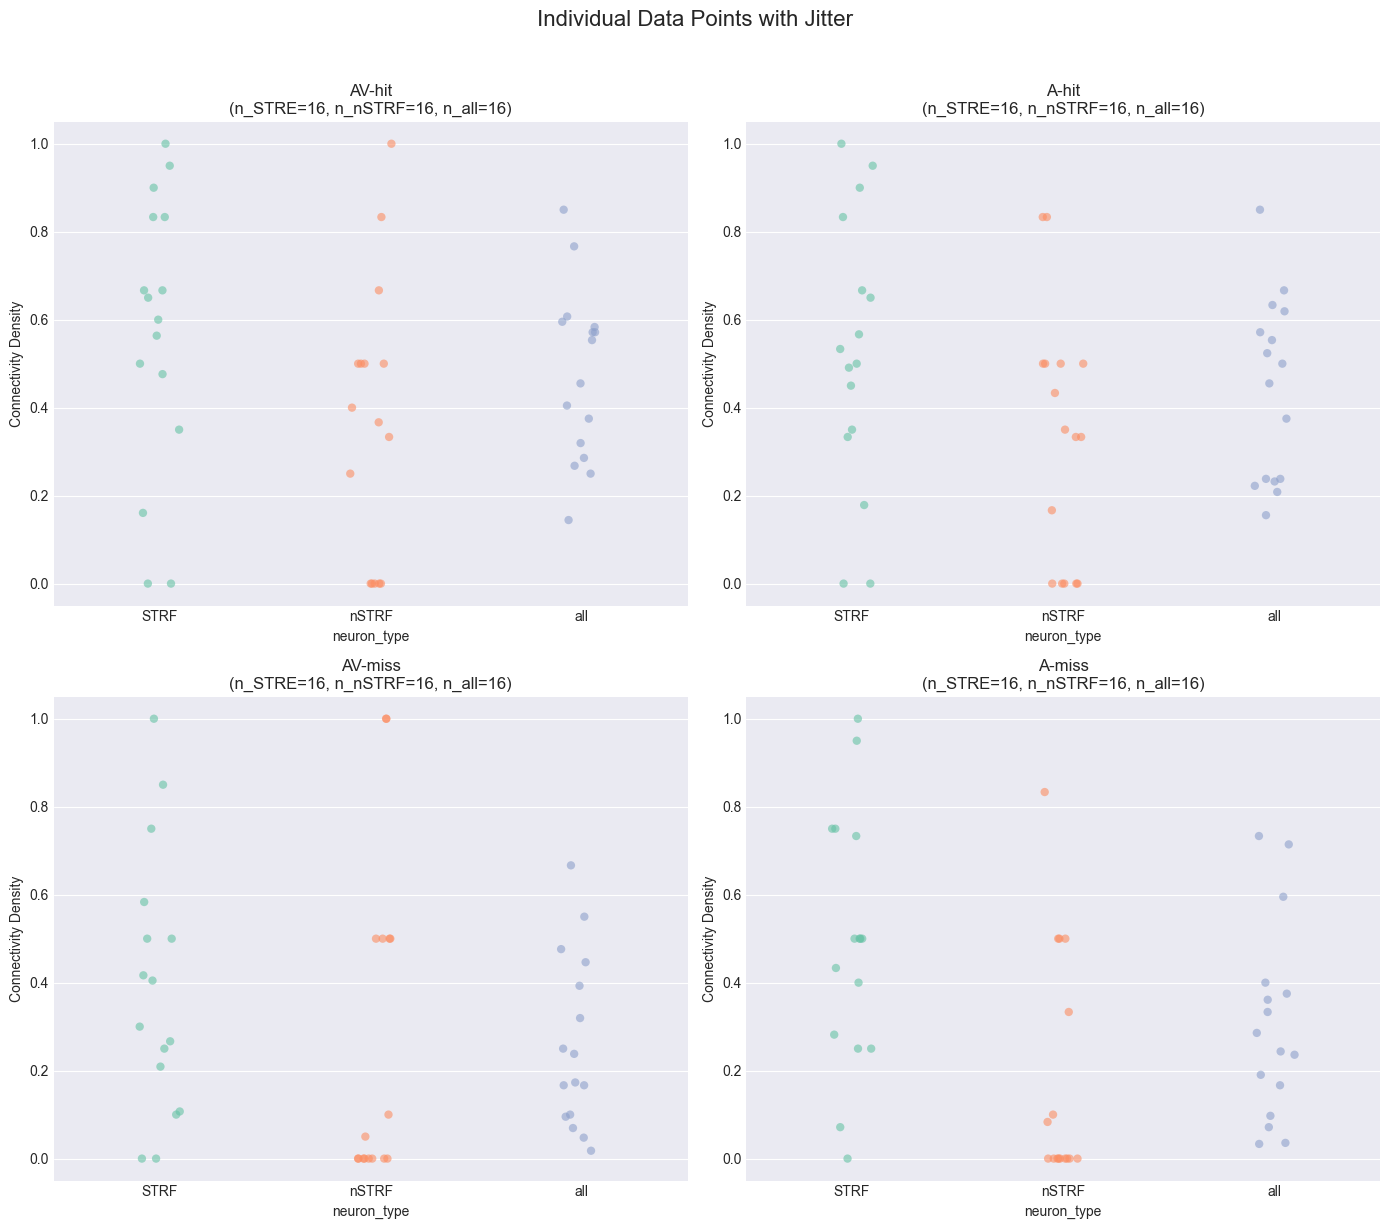

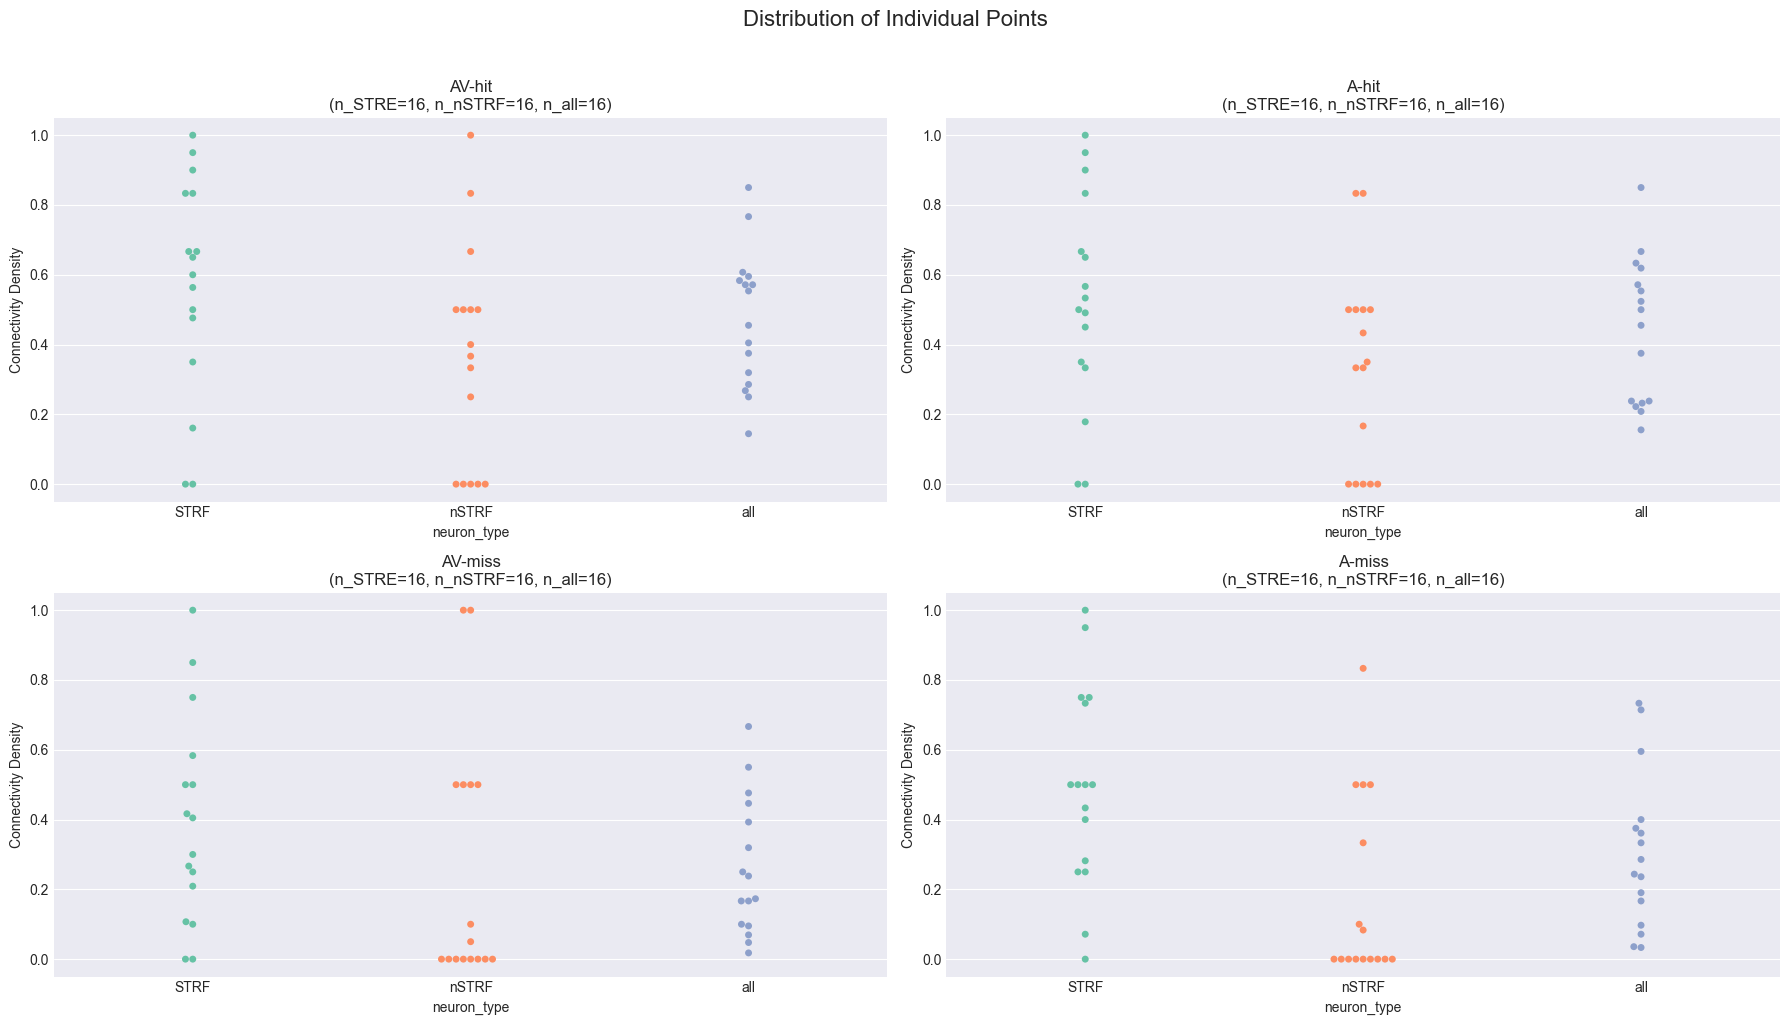


=== SUMMARY TABLE ===
condition neuron_type     mean      std  count      sem
   AV_hit        STRF 0.571909 0.314354     16 0.078588
   AV_hit       nSTRF 0.365625 0.312841     16 0.078210
   AV_hit         all 0.475072 0.195324     16 0.048831
    A_hit        STRF 0.525176 0.308273     16 0.077068
    A_hit       nSTRF 0.330208 0.283380     16 0.070845
    A_hit         all 0.440152 0.206705     16 0.051676
  AV_miss        STRF 0.389854 0.296620     16 0.074155
  AV_miss       nSTRF 0.259375 0.359267     16 0.089817
  AV_miss         all 0.261016 0.195020     16 0.048755
   A_miss        STRF 0.491870 0.288861     16 0.072215
   A_miss       nSTRF 0.178125 0.266439     16 0.066610
   A_miss         all 0.304535 0.221853     16 0.055463


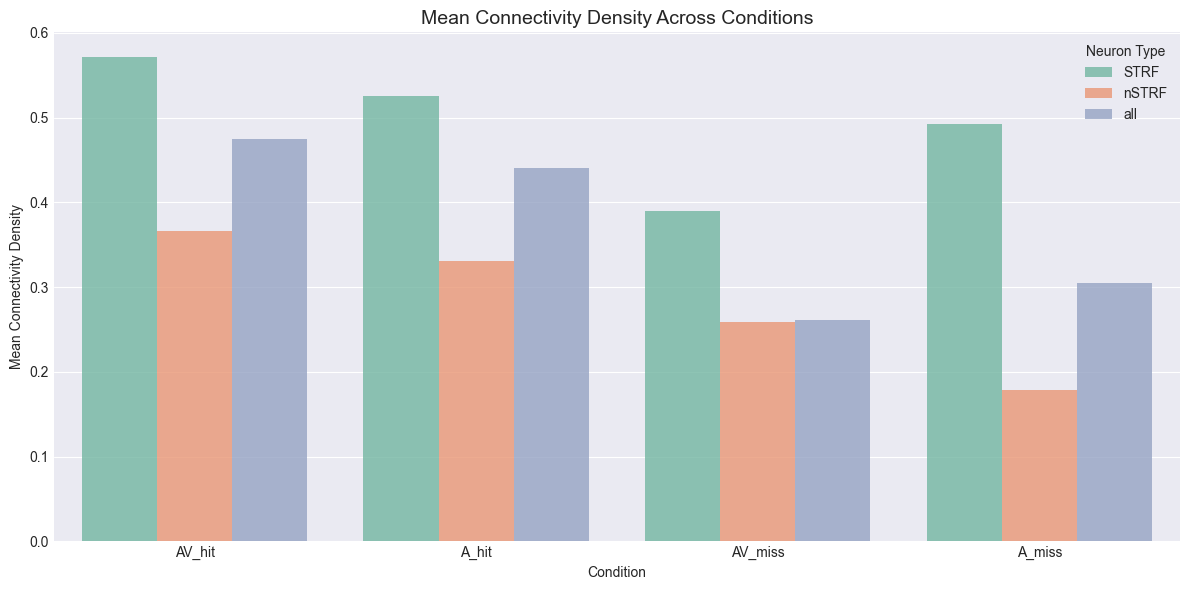

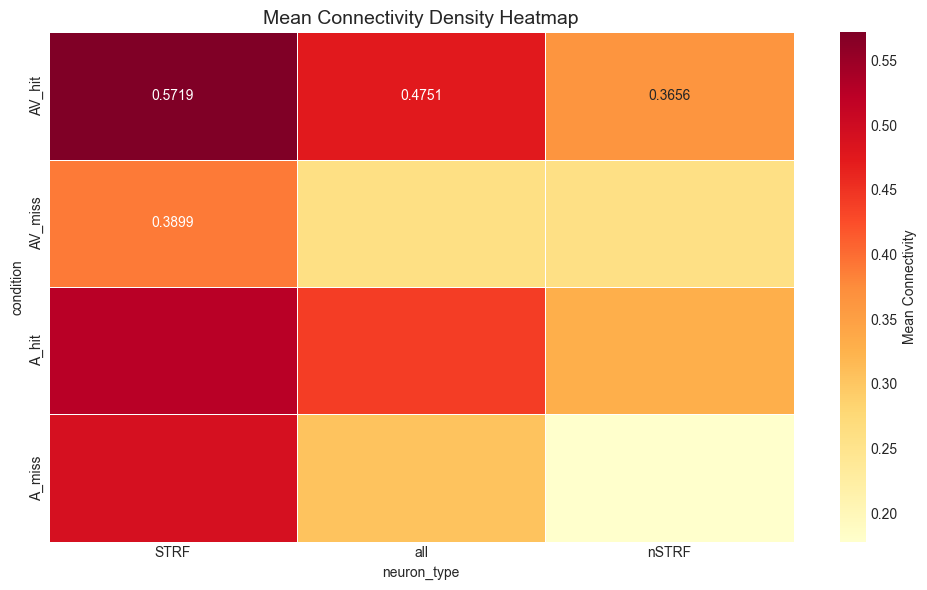

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Define conditions
conditions = [
    ('AV', 'hit'),
    ('A', 'hit'),
    ('AV', 'miss'),
    ('A', 'miss')
]

# Create figure with subplots (2x2 for stripplots and 2x2 for swarmplots)
fig_strip, axes_strip = plt.subplots(2, 2, figsize=(14, 12))
fig_swarm, axes_swarm = plt.subplots(2, 2, figsize=(18, 10))
axes_strip = axes_strip.flatten()
axes_swarm = axes_swarm.flatten()

# Store all results
all_results = {}

for idx, (cond, outcome) in enumerate(conditions):
    # Read files
    strf = pd.read_csv(f'{cond}_{outcome}_STRF.csv', header=None, names=['connectivity'])
    nstrf = pd.read_csv(f'{cond}_{outcome}_nSTRF.csv', header=None, names=['connectivity'])
    all_data = pd.read_csv(f'{cond}_{outcome}_all.csv', header=None, names=['connectivity'])
    
    # Remove NaN values
    strf = strf.dropna()
    nstrf = nstrf.dropna()
    all_data = all_data.dropna()
    
    # Add labels
    strf['neuron_type'] = 'STRF'
    nstrf['neuron_type'] = 'nSTRF'
    all_data['neuron_type'] = 'all'
    
    # Combine data
    combined = pd.concat([strf, nstrf, all_data])
    
    # Calculate statistics
    stats_summary = combined.groupby('neuron_type')['connectivity'].agg(['mean', 'std', 'count', 'sem'])
    stats_summary['sem'] = stats_summary['std'] / np.sqrt(stats_summary['count'])
    
    # Perform t-test between STRF and nSTRF
    t_stat, p_val = stats.ttest_ind(strf['connectivity'], nstrf['connectivity'])
    
    # Store results
    all_results[f'{cond}_{outcome}'] = {
        'stats': stats_summary,
        't_test': {'t': t_stat, 'p': p_val},
        'data': combined
    }
    
    # Print statistics
    print(f"\n=== {cond}-{outcome} ===")
    print(stats_summary.round(4))
    print(f"T-test STRF vs nSTRF: t={t_stat:.4f}, p={p_val:.4f}")
    
    # Create stripplot
    sns.stripplot(data=combined, x='neuron_type', y='connectivity', 
                  jitter=True, size=6, alpha=0.6, 
                  palette=['#66c2a5', '#fc8d62', '#8da0cb'], 
                  ax=axes_strip[idx])
    axes_strip[idx].set_title(f'{cond}-{outcome}\n(n_STRE={len(strf)}, n_nSTRF={len(nstrf)}, n_all={len(all_data)})')
    axes_strip[idx].set_ylabel('Connectivity Density')
    
    # Create swarmplot
    sns.swarmplot(data=combined, x='neuron_type', y='connectivity', 
                  size=5, palette=['#66c2a5', '#fc8d62', '#8da0cb'], 
                  ax=axes_swarm[idx])
    axes_swarm[idx].set_title(f'{cond}-{outcome}\n(n_STRE={len(strf)}, n_nSTRF={len(nstrf)}, n_all={len(all_data)})')
    axes_swarm[idx].set_ylabel('Connectivity Density')

# Adjust layouts and save
fig_strip.suptitle('Individual Data Points with Jitter', fontsize=16, y=1.02)
fig_strip.tight_layout()
fig_strip.savefig('all_conditions_stripplots.png', dpi=300, bbox_inches='tight')

fig_swarm.suptitle('Distribution of Individual Points', fontsize=16, y=1.02)
fig_swarm.tight_layout()
fig_swarm.savefig('all_conditions_swarmplots.png', dpi=300, bbox_inches='tight')

plt.show()

# Create summary dataframe
summary_data = []
for condition, results in all_results.items():
    for neuron_type in ['STRF', 'nSTRF', 'all']:
        summary_data.append({
            'condition': condition,
            'neuron_type': neuron_type,
            'mean': results['stats'].loc[neuron_type, 'mean'],
            'std': results['stats'].loc[neuron_type, 'std'],
            'count': results['stats'].loc[neuron_type, 'count'],
            'sem': results['stats'].loc[neuron_type, 'sem']
        })

summary_df = pd.DataFrame(summary_data)
print("\n=== SUMMARY TABLE ===")
print(summary_df.to_string(index=False))

# Create comparison bar plot
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for bar plot
bar_data = []
for condition in ['AV_hit', 'A_hit', 'AV_miss', 'A_miss']:
    for neuron_type in ['STRF', 'nSTRF', 'all']:
        stats = all_results[condition]['stats'].loc[neuron_type]
        bar_data.append({
            'condition': condition,
            'neuron_type': neuron_type,
            'mean': stats['mean'],
            'sem': stats['sem']
        })

bar_df = pd.DataFrame(bar_data)

# Create grouped bar plot
sns.barplot(data=bar_df, x='condition', y='mean', hue='neuron_type', 
            palette=['#66c2a5', '#fc8d62', '#8da0cb'],
            capsize=0.1, errwidth=1.5, alpha=0.8)

plt.title('Mean Connectivity Density Across Conditions', fontsize=14)
plt.ylabel('Mean Connectivity Density')
plt.xlabel('Condition')
plt.legend(title='Neuron Type')
plt.tight_layout()
plt.savefig('all_conditions_barplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Create heatmap of mean values
pivot_mean = bar_df.pivot(index='condition', columns='neuron_type', values='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_mean, annot=True, fmt='.4f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Mean Connectivity'})
plt.title('Mean Connectivity Density Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('all_conditions_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

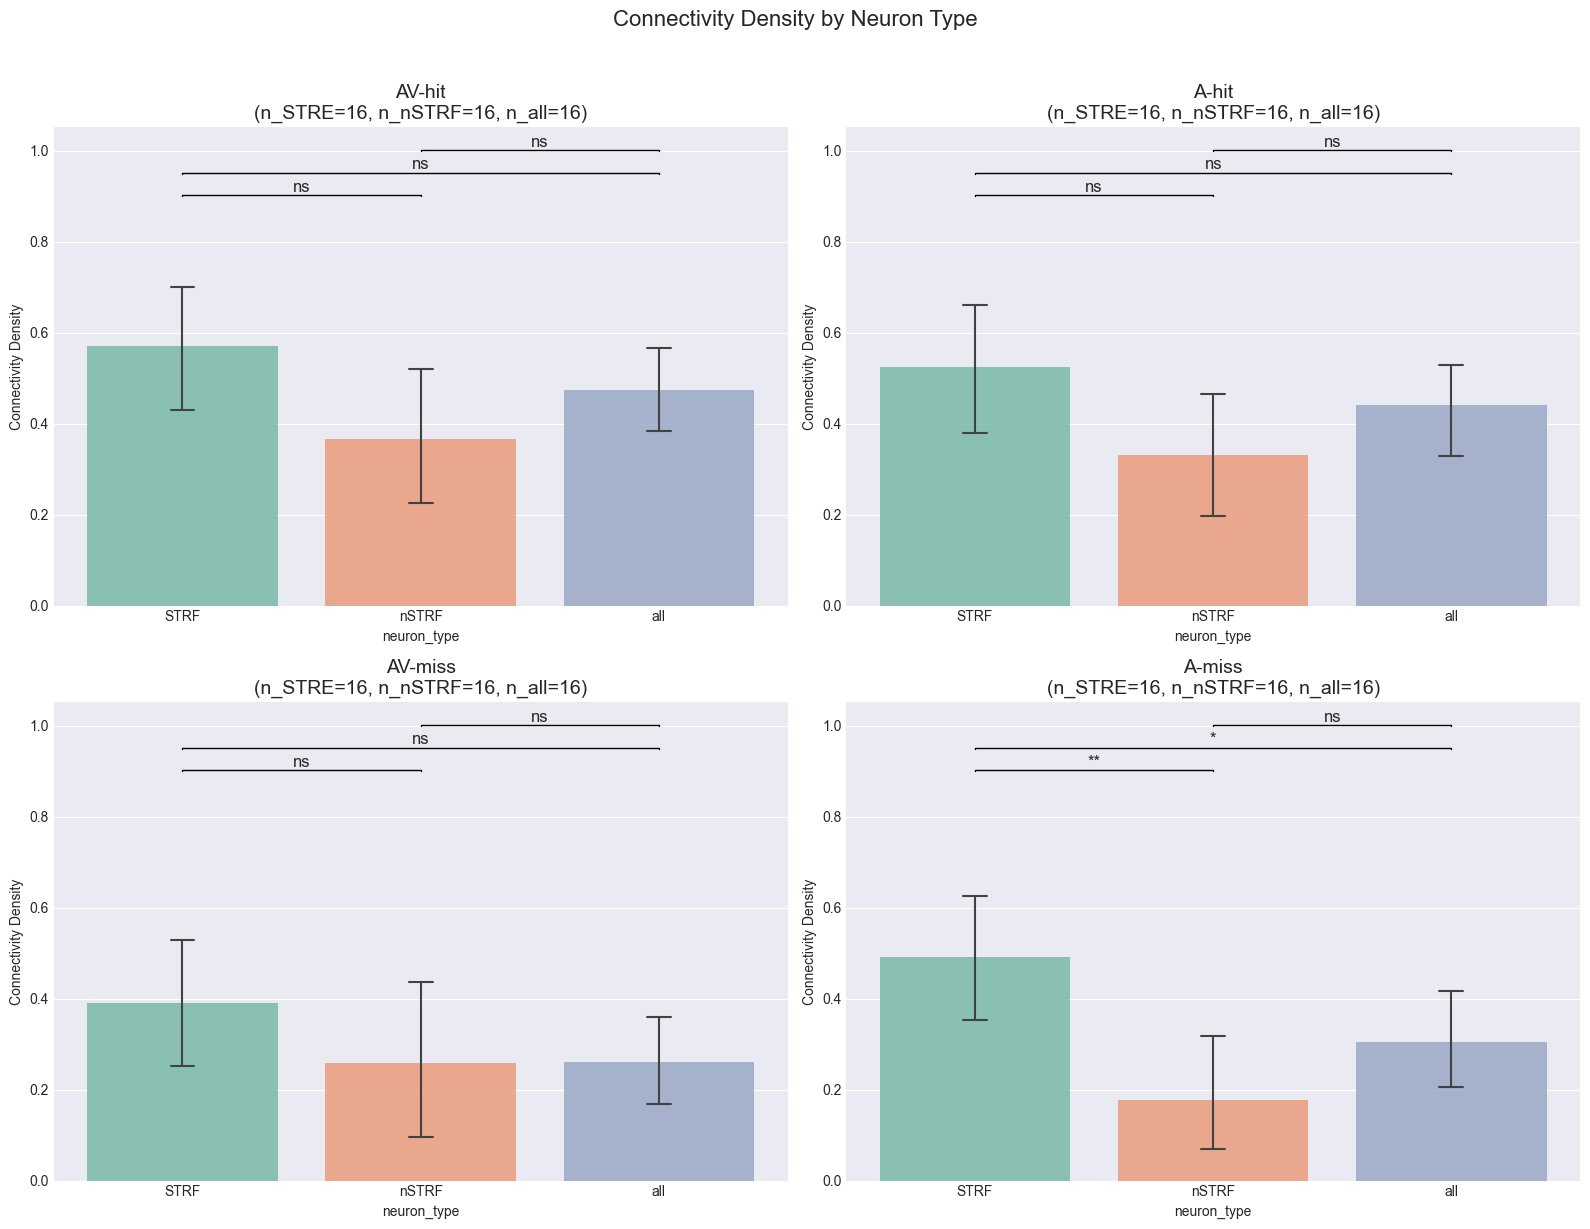


=== P-VALUES ===

AV-hit:
  STRF vs nSTRF: p=0.0726
  STRF vs all:   p=0.3036
  nSTRF vs all:  p=0.2445

A-hit:
  STRF vs nSTRF: p=0.0724
  STRF vs all:   p=0.3668
  nSTRF vs all:  p=0.2196

AV-miss:
  STRF vs nSTRF: p=0.2715
  STRF vs all:   p=0.1570
  nSTRF vs all:  p=0.9873

A-miss:
  STRF vs nSTRF: p=0.0033
  STRF vs all:   p=0.0484
  nSTRF vs all:  p=0.1551


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Define conditions
conditions = [
    ('AV', 'hit'),
    ('A', 'hit'),
    ('AV', 'miss'),
    ('A', 'miss')
]

# Create figure with subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Function to add significance bars
def add_sig_bar(ax, x1, x2, y, p_val):
    # Determine symbol
    if p_val < 0.001:
        symbol = '***'
    elif p_val < 0.01:
        symbol = '**'
    elif p_val < 0.05:
        symbol = '*'
    else:
        symbol = 'ns'
    
    # Draw bar and text
    ax.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], 'k-', linewidth=1)
    ax.text((x1+x2)/2, y+0.003, symbol, ha='center', va='bottom', fontsize=12)

for idx, (cond, outcome) in enumerate(conditions):
    # Read files
    strf = pd.read_csv(f'{cond}_{outcome}_STRF.csv', header=None, names=['connectivity']).dropna()
    nstrf = pd.read_csv(f'{cond}_{outcome}_nSTRF.csv', header=None, names=['connectivity']).dropna()
    all_data = pd.read_csv(f'{cond}_{outcome}_all.csv', header=None, names=['connectivity']).dropna()
    
    # Add labels and combine
    strf['neuron_type'] = 'STRF'
    nstrf['neuron_type'] = 'nSTRF'
    all_data['neuron_type'] = 'all'
    combined = pd.concat([strf, nstrf, all_data])
    
    # Calculate statistics
    stats_summary = combined.groupby('neuron_type')['connectivity'].agg(['mean', 'sem'])
    
    # Perform t-tests
    p_strf_nstrf = stats.ttest_ind(strf['connectivity'], nstrf['connectivity'])[1]
    p_strf_all = stats.ttest_ind(strf['connectivity'], all_data['connectivity'])[1]
    p_nstrf_all = stats.ttest_ind(nstrf['connectivity'], all_data['connectivity'])[1]
    
    # Create barplot (exactly as before)
    ax = axes[idx]
    sns.barplot(data=combined, x='neuron_type', y='connectivity', 
                order=['STRF', 'nSTRF', 'all'],
                palette=['#66c2a5', '#fc8d62', '#8da0cb'], 
                capsize=0.1, errwidth=1.5, alpha=0.8, ax=ax)
    
    # Add title with sample sizes
    ax.set_title(f'{cond}-{outcome}\n(n_STRE={len(strf)}, n_nSTRF={len(nstrf)}, n_all={len(all_data)})', fontsize=14)
    ax.set_ylabel('Connectivity Density')
    
    # Get y-axis max for positioning significance bars
    y_max = combined['connectivity'].max()
    
    # Add significance bars
    add_sig_bar(ax, 0, 1, 0.9       , p_strf_nstrf)  # STRF vs nSTRF
    add_sig_bar(ax, 0, 2, 0.9 + 0.05, p_strf_all)    # STRF vs all
    add_sig_bar(ax, 1, 2, 0.9 + 0.10, p_nstrf_all)   # nSTRF vs all

plt.suptitle('Connectivity Density by Neuron Type', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('all_conditions_barplot_with_significance.png', dpi=300, bbox_inches='tight')
plt.show()

# Print all p-values
print("\n=== P-VALUES ===")
for cond, outcome in conditions:
    strf = pd.read_csv(f'{cond}_{outcome}_STRF.csv', header=None, names=['connectivity']).dropna()
    nstrf = pd.read_csv(f'{cond}_{outcome}_nSTRF.csv', header=None, names=['connectivity']).dropna()
    all_data = pd.read_csv(f'{cond}_{outcome}_all.csv', header=None, names=['connectivity']).dropna()
    
    p1 = stats.ttest_ind(strf['connectivity'], nstrf['connectivity'])[1]
    p2 = stats.ttest_ind(strf['connectivity'], all_data['connectivity'])[1]
    p3 = stats.ttest_ind(nstrf['connectivity'], all_data['connectivity'])[1]
    
    print(f"\n{cond}-{outcome}:")
    print(f"  STRF vs nSTRF: p={p1:.4f}")
    print(f"  STRF vs all:   p={p2:.4f}")
    print(f"  nSTRF vs all:  p={p3:.4f}")

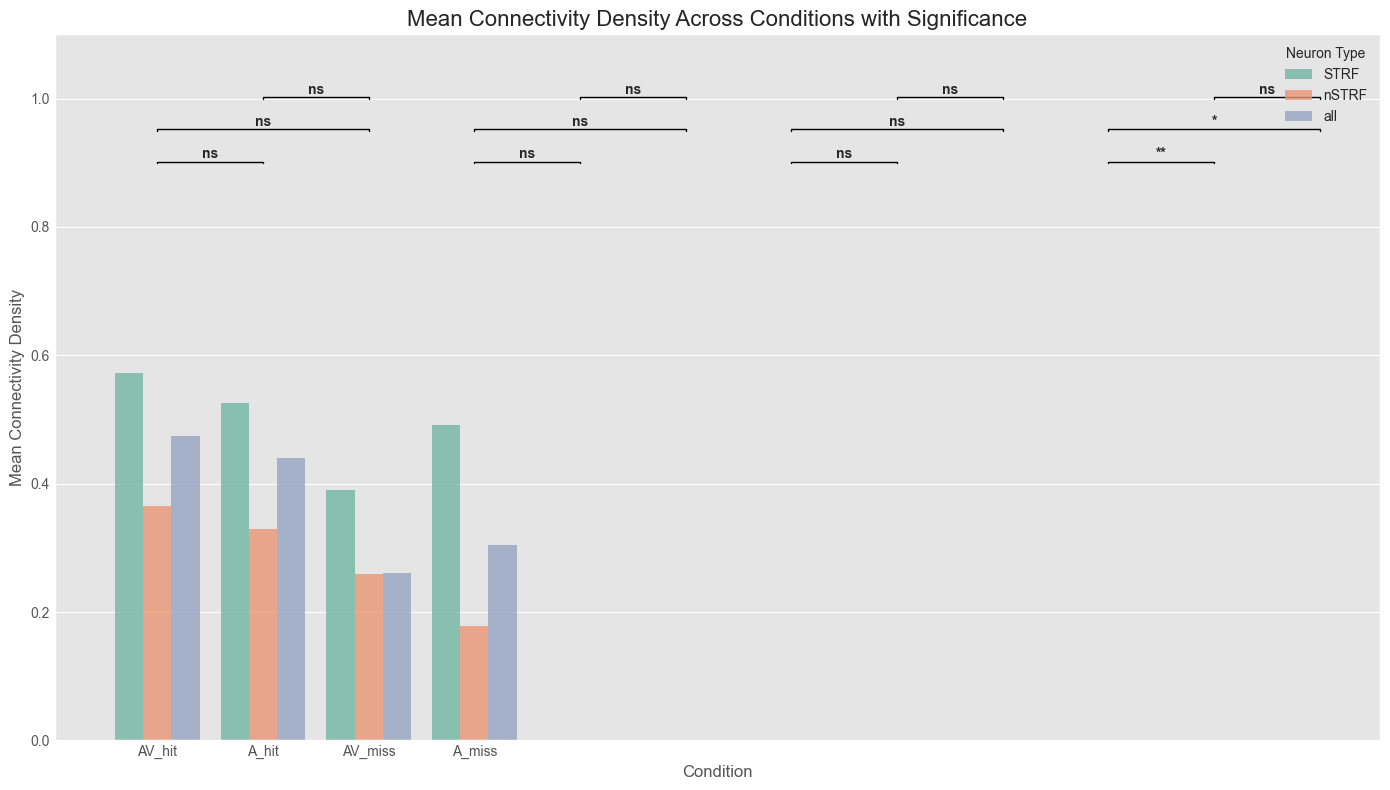


=== P-VALUES ===

AV_hit:
  STRF vs nSTRF: p=0.0726 
  STRF vs all:   p=0.3036 
  nSTRF vs all:  p=0.2445 

A_hit:
  STRF vs nSTRF: p=0.0724 
  STRF vs all:   p=0.3668 
  nSTRF vs all:  p=0.2196 

AV_miss:
  STRF vs nSTRF: p=0.2715 
  STRF vs all:   p=0.1570 
  nSTRF vs all:  p=0.9873 

A_miss:
  STRF vs nSTRF: p=0.0033 *
  STRF vs all:   p=0.0484 *
  nSTRF vs all:  p=0.1551 


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('ggplot')
sns.set_palette("Set2")

# Define conditions
conditions = [
    ('AV', 'hit'),
    ('A', 'hit'),
    ('AV', 'miss'),
    ('A', 'miss')
]

# Store all results
all_results = {}

for cond, outcome in conditions:
    condition_name = f'{cond}_{outcome}'
    
    # Read files exactly as in your corrected code
    strf = pd.read_csv(f'{cond}_{outcome}_STRF.csv', header=None, names=['connectivity']).dropna()
    nstrf = pd.read_csv(f'{cond}_{outcome}_nSTRF.csv', header=None, names=['connectivity']).dropna()
    all_data = pd.read_csv(f'{cond}_{outcome}_all.csv', header=None, names=['connectivity']).dropna()
    
    # Add labels
    strf['neuron_type'] = 'STRF'
    nstrf['neuron_type'] = 'nSTRF'
    all_data['neuron_type'] = 'all'
    
    # Store the dataframes for later use
    all_results[condition_name] = {
        'strf': strf,
        'nstrf': nstrf,
        'all': all_data
    }

# Function to add significance bars
def add_sig_bar(ax, x1, x2, y, p_val):
    # Determine symbol
    if p_val < 0.001:
        symbol = '***'
    elif p_val < 0.01:
        symbol = '**'
    elif p_val < 0.05:
        symbol = '*'
    else:
        symbol = 'ns'
    
    # Draw bar and text
    ax.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], 'k-', linewidth=1)
    ax.text((x1+x2)/2, y+0.003, symbol, ha='center', va='bottom', fontsize=10, fontweight='bold')

# Create the grouped bar plot
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for bar plot
bar_data = []
condition_order = ['AV_hit', 'A_hit', 'AV_miss', 'A_miss']
neuron_order = ['STRF', 'nSTRF', 'all']

for condition in condition_order:
    # Get the dataframes for this condition
    strf_df = all_results[condition]['strf']
    nstrf_df = all_results[condition]['nstrf']
    all_df = all_results[condition]['all']
    
    # Calculate statistics
    for neuron_type, df in zip(['STRF', 'nSTRF', 'all'], [strf_df, nstrf_df, all_df]):
        mean_val = df['connectivity'].mean()
        sem_val = df['connectivity'].sem()
        
        bar_data.append({
            'condition': condition,
            'neuron_type': neuron_type,
            'mean': mean_val,
            'sem': sem_val
        })

bar_df = pd.DataFrame(bar_data)

# Create grouped bar plot
sns.barplot(data=bar_df, x='condition', y='mean', hue='neuron_type', 
            palette=['#66c2a5', '#fc8d62', '#8da0cb'],
            capsize=0.1, errwidth=1.5, alpha=0.8, ax=ax)

# Add significance bars for each condition group
for i, condition in enumerate(condition_order):
    # Get the dataframes for this condition
    strf_df = all_results[condition]['strf']
    nstrf_df = all_results[condition]['nstrf']
    all_df = all_results[condition]['all']
    
    # Perform t-tests exactly as in your corrected code
    p_strf_nstrf = stats.ttest_ind(strf_df['connectivity'], nstrf_df['connectivity'])[1]
    p_strf_all = stats.ttest_ind(strf_df['connectivity'], all_df['connectivity'])[1]
    p_nstrf_all = stats.ttest_ind(nstrf_df['connectivity'], all_df['connectivity'])[1]
    
    # Calculate x positions for this condition group
    base_x = i * 3
    
    # Add significance bars at specified y positions
    add_sig_bar(ax, base_x + 0, base_x + 1, 0.9, p_strf_nstrf)        # STRF vs nSTRF
    add_sig_bar(ax, base_x + 0, base_x + 2, 0.9 + 0.05, p_strf_all)   # STRF vs all
    add_sig_bar(ax, base_x + 1, base_x + 2, 0.9 + 0.10, p_nstrf_all)  # nSTRF vs all

# Customize plot
plt.title('Mean Connectivity Density Across Conditions with Significance', fontsize=16)
plt.ylabel('Mean Connectivity Density', fontsize=12)
plt.xlabel('Condition', fontsize=12)
plt.legend(title='Neuron Type', loc='upper right')

# Adjust y-axis to make room for significance bars
plt.ylim(0, 1.1)

plt.tight_layout()
plt.savefig('all_conditions_grouped_barplot_significance.png', dpi=300, bbox_inches='tight')
plt.show()

# Print all p-values
print("\n=== P-VALUES ===")
for condition in condition_order:
    strf_df = all_results[condition]['strf']
    nstrf_df = all_results[condition]['nstrf']
    all_df = all_results[condition]['all']
    
    p1 = stats.ttest_ind(strf_df['connectivity'], nstrf_df['connectivity'])[1]
    p2 = stats.ttest_ind(strf_df['connectivity'], all_df['connectivity'])[1]
    p3 = stats.ttest_ind(nstrf_df['connectivity'], all_df['connectivity'])[1]
    
    print(f"\n{condition}:")
    print(f"  STRF vs nSTRF: p={p1:.4f} {'*' if p1<0.05 else ''}")
    print(f"  STRF vs all:   p={p2:.4f} {'*' if p2<0.05 else ''}")
    print(f"  nSTRF vs all:  p={p3:.4f} {'*' if p3<0.05 else ''}")

# Paired comparisons

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# Read the files
av_hit_strf = pd.read_csv('AV_hit_STRF.csv', header=None, names=['STRF'])
av_hit_nstrf = pd.read_csv('AV_hit_nSTRF.csv', header=None, names=['nSTRF'])
av_hit_all = pd.read_csv('AV_hit_all.csv', header=None, names=['all'])

# Combine into one dataframe
combined = pd.concat([av_hit_strf, av_hit_nstrf, av_hit_all], axis=1)

# Remove rows with any NaN values
combined_clean = combined.dropna()

print(f"Original rows: {len(combined)}")
print(f"Rows after removing NaN: {len(combined_clean)}")
print(f"Rows removed: {len(combined) - len(combined_clean)}")

# Show first few rows of clean data
print("\nFirst 5 rows of clean data:")
print(combined_clean.head())

# Basic statistics
print("\nStatistics for clean data:")
print(combined_clean.describe())

# Correlation between STRF and nSTRF
correlation = combined_clean['STRF'].corr(combined_clean['nSTRF'])
print(f"\nCorrelation between STRF and nSTRF: {correlation:.4f}")

Original rows: 73
Rows after removing NaN: 16
Rows removed: 57

First 5 rows of clean data:
        STRF     nSTRF       all
1   1.000000  0.833333  0.850000
3   0.833333  1.000000  0.595238
6   0.160714  0.000000  0.144444
8   0.000000  0.500000  0.583333
13  0.350000  0.250000  0.250000

Statistics for clean data:
            STRF      nSTRF        all
count  16.000000  16.000000  16.000000
mean    0.571909   0.365625   0.475072
std     0.314354   0.312841   0.195324
min     0.000000   0.000000   0.144444
25%     0.444643   0.000000   0.311012
50%     0.625000   0.383333   0.504350
75%     0.833333   0.500000   0.586310
max     1.000000   1.000000   0.850000

Correlation between STRF and nSTRF: 0.3372


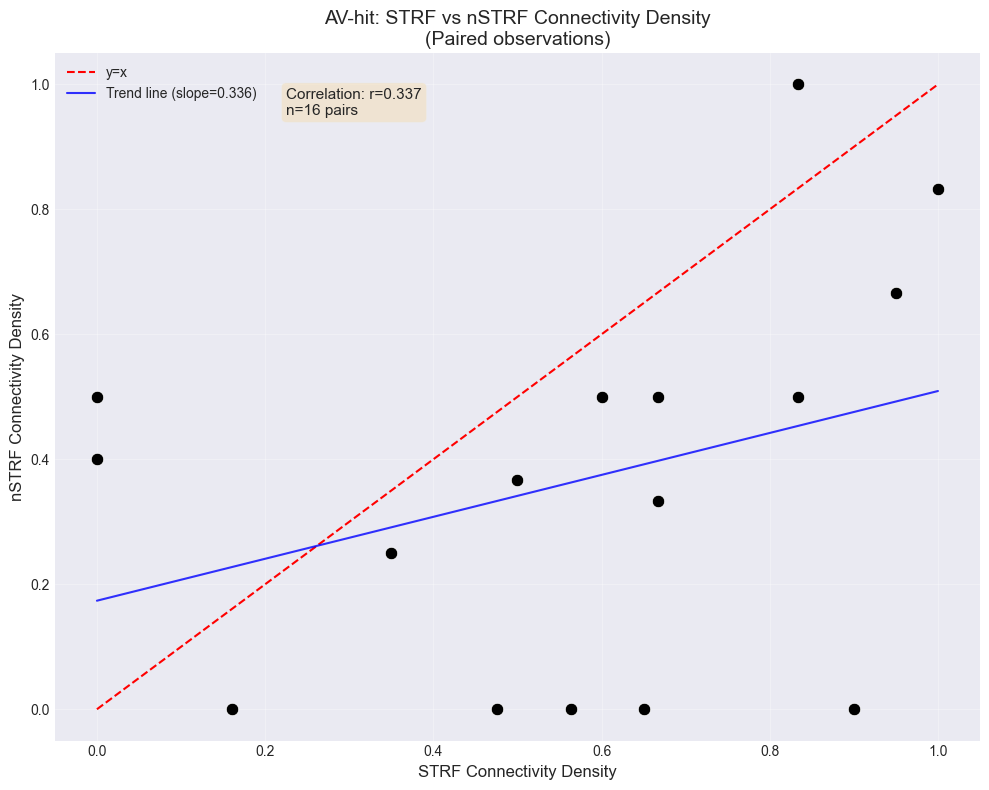

In [8]:
# Create scatter plot
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter plot
scatter = ax.scatter(combined_clean['STRF'], combined_clean['nSTRF'], 
                 s=80, c='black', edgecolors='white', linewidth=0.5)

# Add diagonal line (y=x) for reference
min_val = min(combined_clean[['STRF', 'nSTRF']].min())
max_val = max(combined_clean[['STRF', 'nSTRF']].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='y=x')

# Add trend line
z = np.polyfit(combined_clean['STRF'], combined_clean['nSTRF'], 1)
p = np.poly1d(z)
ax.plot(combined_clean['STRF'].sort_values(), 
        p(combined_clean['STRF'].sort_values()), 
        'b-', alpha=0.8, label=f'Trend line (slope={z[0]:.3f})')

ax.set_xlabel('STRF Connectivity Density', fontsize=12)
ax.set_ylabel('nSTRF Connectivity Density', fontsize=12)
ax.set_title('AV-hit: STRF vs nSTRF Connectivity Density\n(Paired observations)', fontsize=14)

# Add text with statistics
stats_text = f'Correlation: r={correlation:.3f}\n'
stats_text += f'n={len(combined_clean)} pairs'
ax.text(0.25, 0.95, stats_text, transform=ax.transAxes, 
        fontsize=11, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('AV_hit_STRF_vs_nSTRF_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

AV-hit: n=16, r=0.337
A-hit: n=16, r=0.306
AV-miss: n=16, r=0.411
A-miss: n=16, r=0.247


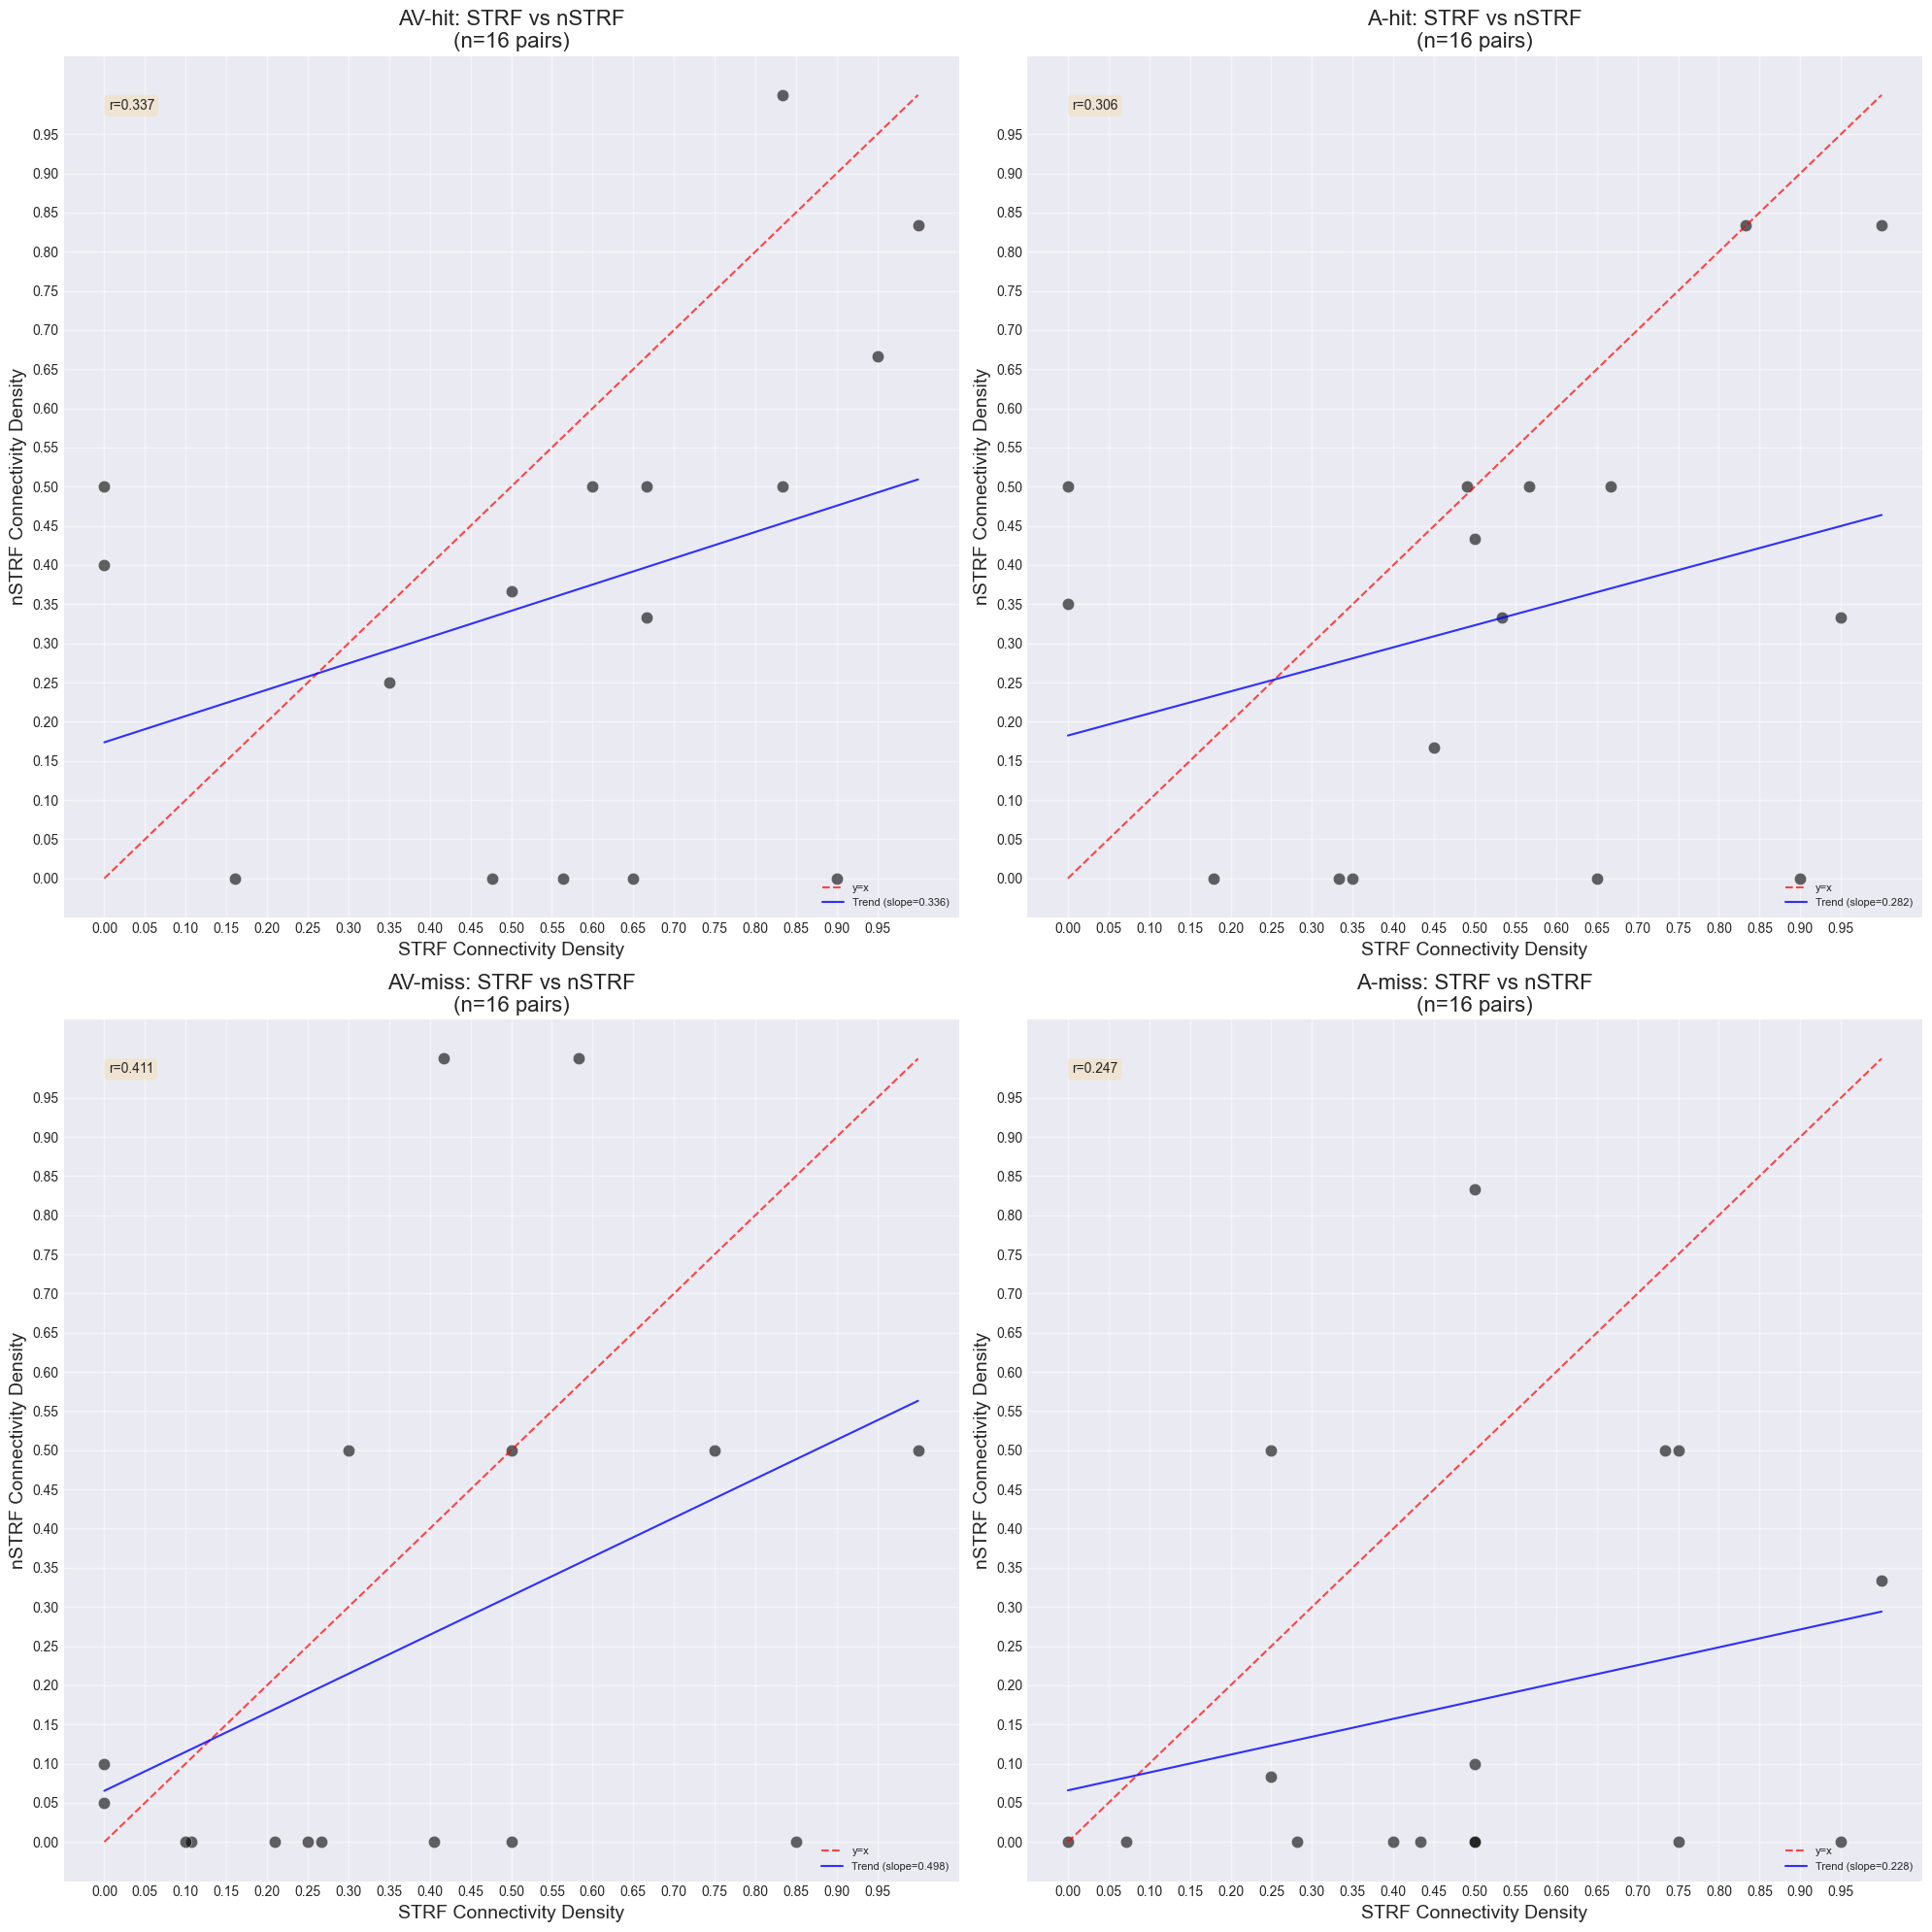


=== SUMMARY ===
            n  correlation
AV_hit   16.0     0.337181
A_hit    16.0     0.306272
AV_miss  16.0     0.411080
A_miss   16.0     0.247451


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

# Define conditions
conditions = [
    ('AV', 'hit'),
    ('A', 'hit'),
    ('AV', 'miss'),
    ('A', 'miss')
]

# Create figure with subplots (2x2)
fig, axes = plt.subplots(2, 2, figsize=(20, 20))
axes = axes.flatten()

# Store statistics
all_stats = {}

for idx, (cond, outcome) in enumerate(conditions):
    # Read files
    strf = pd.read_csv(f'{cond}_{outcome}_STRF.csv', header=None, names=['STRF'])
    nstrf = pd.read_csv(f'{cond}_{outcome}_nSTRF.csv', header=None, names=['nSTRF'])
    all_data = pd.read_csv(f'{cond}_{outcome}_all.csv', header=None, names=['all'])
    
    # Combine and clean
    combined = pd.concat([strf, nstrf, all_data], axis=1).dropna()
    
    # Store stats
    all_stats[f'{cond}_{outcome}'] = {
        'n': len(combined),
        'correlation': combined['STRF'].corr(combined['nSTRF'])
    }
    
    # Calculate trend line
    z = np.polyfit(combined['STRF'], combined['nSTRF'], 1)
    p = np.poly1d(z)
    
    # Plot
    ax = axes[idx]
    
    # Scatter plot
    ax.scatter(combined['STRF'], combined['nSTRF'], 
               s=80, c='black', alpha=0.6, edgecolors='white', linewidth=0.5)
    
    # Diagonal line (y=x)
    min_val = min(combined[['STRF', 'nSTRF']].min())
    max_val = max(combined[['STRF', 'nSTRF']].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='y=x')
    
    # Trend line
    x_sorted = combined['STRF'].sort_values()
    ax.plot(x_sorted, p(x_sorted), 'b-', alpha=0.8, 
            label=f'Trend (slope={z[0]:.3f})')
    
    # Labels and title
    ax.set_xlabel('STRF Connectivity Density', fontsize=14)
    ax.set_ylabel('nSTRF Connectivity Density', fontsize=14)
    ax.set_title(f'{cond}-{outcome}: STRF vs nSTRF\n(n={len(combined)} pairs)', fontsize=16)
    # This sets major ticks every 0.05
    ax.set_xticks(np.arange(0, 1, 0.05))
    ax.set_yticks(np.arange(0, 1, 0.05))
    
    # Statistics text
    stats_text = f'r={all_stats[f"{cond}_{outcome}"]["correlation"]:.3f}'
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.legend(loc='lower right', fontsize=8)
    
    ax.grid(True, alpha=0.5, which='both', linestyle='-', linewidth=1)
    
    # Print individual stats
    print(f"{cond}-{outcome}: n={len(combined)}, r={all_stats[f'{cond}_{outcome}']['correlation']:.3f}")

plt.tight_layout()
plt.savefig('all_conditions_STRF_vs_nSTRF.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n=== SUMMARY ===")
summary_df = pd.DataFrame(all_stats).T
print(summary_df)